In [1]:
!nvidia-smi

Mon Mar 23 17:23:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.211.01             Driver Version: 570.211.01     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090        Off |   00000000:01:00.0  On |                  Off |
|  0%   38C    P8             18W /  450W |    3444MiB /  24564MiB |     14%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch
import jax
import jax.numpy as jnp
import numpy as np


# 1. Create a function that performs 10 elementwise ops on a big (5000x5000) matrix
def np_ops(x):
    x = np.sin(x)
    x = np.cos(x)
    x = x + 10
    x = np.exp(x)
    x = x // 3
    x = np.acosh(x)
    x = np.asinh(x)
    x = x * 6.3
    x = x - 3.141098
    x = np.exp(x)

    return x

def jax_ops(x):
    x = jnp.sin(x)
    x = jnp.cos(x)
    x = x + 10
    x = jnp.exp(x)
    x = x // 3
    x = jnp.acosh(x)
    x = jnp.asinh(x)
    x = x * 6.3
    x = x - 3.141098
    x = jnp.exp(x)

    return x

@jax.jit
def jit_jax_ops(x):
    x = jnp.sin(x)
    x = jnp.cos(x)
    x = x + 10
    x = jnp.exp(x)
    x = x // 3
    x = jnp.acosh(x)
    x = jnp.asinh(x)
    x = x * 6.3
    x = x - 3.141098
    x = jnp.exp(x)

    return x

In [3]:
def human_readable_time(seconds):
    """
    Converts a time duration in seconds into a human readable string.
    """
    if seconds < 1e-6:
        return f"{seconds*1e9:.2f} ns"
    elif seconds < 1e-3:
        return f"{seconds*1e6:.2f} μs"
    elif seconds < 1:
        return f"{seconds*1e3:.2f} ms"
    else:
        return f"{seconds:.3f} s"

In [4]:
import time
sizes = [100, 500, 1000, 5000]
np_eager_times = []
jnp_eager_times = []
first_jit_times = []
second_jit_times = []


for size in sizes:
    print(f"\nSize: {size}")

    # 2. time eager mode (no @jit), first call with @jit (include compilation), second call with @jit (cached compilation)
    np_matrix = np.random.randn(size, size)
    key = jax.random.PRNGKey(17)
    jax_matrix = jax.random.normal(key, (size, size))

    # eager mode, with different libraries for elementwise operations, numpy, jax, and torch
    # print("Eager mode for numpy, jax, and torch")
    start = time.perf_counter()
    out = np_ops(np_matrix)
    np_eager_times.append(time.perf_counter() - start)
    print("Numpy eager run: ", human_readable_time(np_eager_times[-1]))

    start = time.perf_counter()
    out = jax_ops(jax_matrix)
    jnp_eager_times.append(time.perf_counter() - start)
    print("JAX eager run: ", human_readable_time(jnp_eager_times[-1]))

    # first call with @jit (include compilation), second call with @jit (cached compilation)
    start = time.perf_counter() 
    out = jit_jax_ops(jax_matrix).block_until_ready()
    first_jit_times.append(time.perf_counter() - start)
    print("First JIT run: ", human_readable_time(first_jit_times[-1]))

    # second call with @jit (cached compilation)
    start = time.perf_counter()
    out = jit_jax_ops(jax_matrix).block_until_ready()
    second_jit_times.append(time.perf_counter() - start)
    print("Second JIT run: ", human_readable_time(second_jit_times[-1]))




Size: 100
Numpy eager run:  415.28 μs
JAX eager run:  251.89 ms
First JIT run:  54.12 ms
Second JIT run:  164.36 μs

Size: 500
Numpy eager run:  9.32 ms
JAX eager run:  318.73 ms
First JIT run:  68.73 ms
Second JIT run:  146.68 μs

Size: 1000
Numpy eager run:  38.08 ms
JAX eager run:  315.41 ms
First JIT run:  59.89 ms
Second JIT run:  88.10 μs

Size: 5000
Numpy eager run:  1.034 s
JAX eager run:  287.71 ms
First JIT run:  57.85 ms
Second JIT run:  724.04 μs


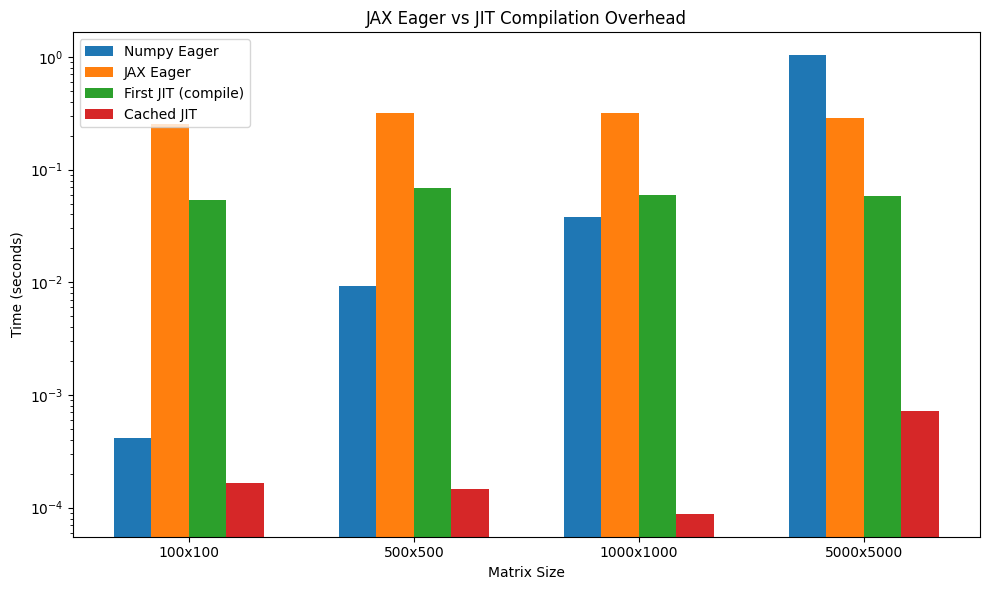

In [5]:
import matplotlib.pyplot as plt

# Increase spacing between bars/groups
group_width = 1.5  # Control gap between groups
x = np.arange(len(sizes)) * group_width
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, np_eager_times, width, label='Numpy Eager')
ax.bar(x,          jnp_eager_times, width, label='JAX Eager')
ax.bar(x + width,  first_jit_times, width, label='First JIT (compile)')
ax.bar(x + 2*width,  second_jit_times, width, label='Cached JIT')

ax.set_xlabel('Matrix Size')
ax.set_ylabel('Time (seconds)')
ax.set_title('JAX Eager vs JIT Compilation Overhead')
ax.set_xticks(x + width / 2)  # Slight adjust for centered group tick
ax.set_xticklabels([f'{s}x{s}' for s in sizes])
ax.legend()
ax.set_yscale('log')  # log scale helps since the range spans orders of magnitude
plt.tight_layout()
plt.show()

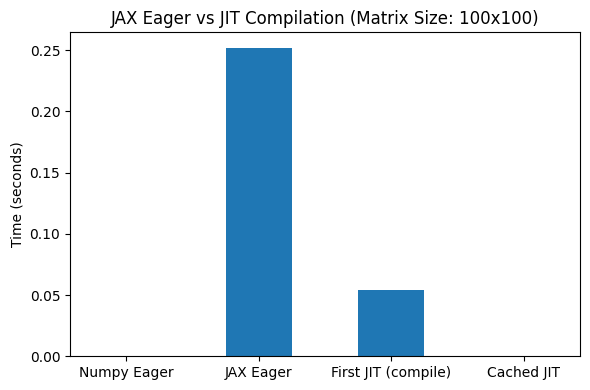

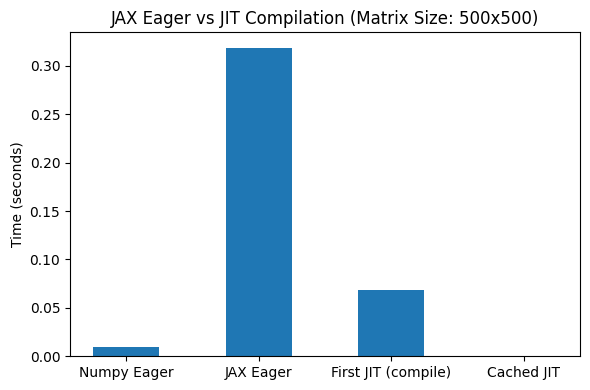

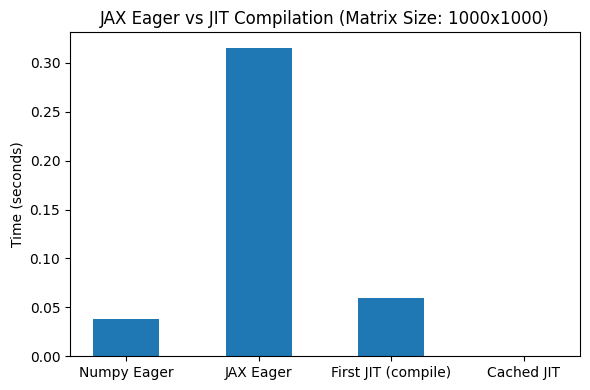

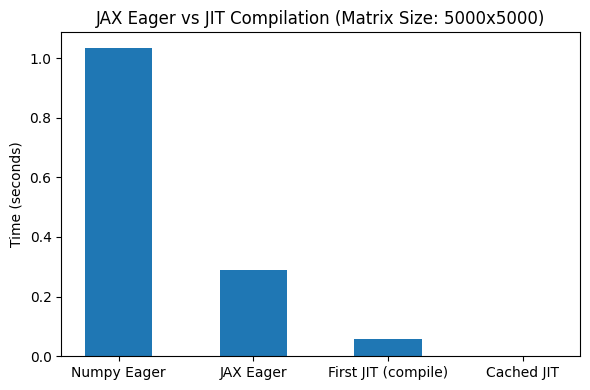

In [6]:
# Make a separate bar plot for each size

for i, size in enumerate(sizes):
    fig, ax = plt.subplots(figsize=(6, 4))
    bars = [
        np_eager_times[i],
        jnp_eager_times[i],
        first_jit_times[i],
        second_jit_times[i]
    ]
    labels = ['Numpy Eager', 'JAX Eager', 'First JIT (compile)', 'Cached JIT']
    ax.bar(labels, bars, width=0.5)
    ax.set_ylabel('Time (seconds)')
    ax.set_title(f'JAX Eager vs JIT Compilation (Matrix Size: {size}x{size})')
    plt.tight_layout()
    plt.show()

As the size of the matrix increases, the compilation time in proportion to the total time grows. This is due to the amount of time it takes to actually run the function and trace it.

In [7]:
@jax.jit
def jit_mean_matrix_row(x):
    return jnp.mean(x, axis=1)

In [8]:
sizes = [(100, 100), (100, 200), (100, 100), (200, 100)]
first_jit_times = []
second_jit_times = []

for size in sizes:
    print(f"\nSize: {size}")
    key = jax.random.PRNGKey(17)
    jax_matrix = jax.random.normal(key, (size[0], size[1]))

    start = time.perf_counter() 
    out = jit_mean_matrix_row(jax_matrix).block_until_ready()
    first_jit_times.append(time.perf_counter() - start)
    print("First JIT run: ", human_readable_time(first_jit_times[-1]))

    start = time.perf_counter()
    out = jit_mean_matrix_row(jax_matrix).block_until_ready()
    second_jit_times.append(time.perf_counter() - start)
    print("Second JIT run: ", human_readable_time(second_jit_times[-1]))

    print(jax.make_jaxpr(jit_mean_matrix_row)(jax_matrix))




Size: (100, 100)
First JIT run:  93.94 ms
Second JIT run:  160.72 μs
{ lambda ; a:f32[100,100]. let
    b:f32[100] = jit[
      name=jit_mean_matrix_row
      jaxpr={ lambda ; a:f32[100,100]. let
          c:f32[100] = reduce_sum[axes=(1,) out_sharding=None] a
          b:f32[100] = div c 100.0:f32[]
        in (b,) }
    ] a
  in (b,) }

Size: (100, 200)
First JIT run:  78.44 ms
Second JIT run:  138.23 μs
{ lambda ; a:f32[100,200]. let
    b:f32[100] = jit[
      name=jit_mean_matrix_row
      jaxpr={ lambda ; a:f32[100,200]. let
          c:f32[100] = reduce_sum[axes=(1,) out_sharding=None] a
          b:f32[100] = div c 200.0:f32[]
        in (b,) }
    ] a
  in (b,) }

Size: (100, 100)
First JIT run:  84.84 μs
Second JIT run:  255.64 μs
{ lambda ; a:f32[100,100]. let
    b:f32[100] = jit[
      name=jit_mean_matrix_row
      jaxpr={ lambda ; a:f32[100,100]. let
          c:f32[100] = reduce_sum[axes=(1,) out_sharding=None] a
          b:f32[100] = div c 100.0:f32[]
        in (b,)

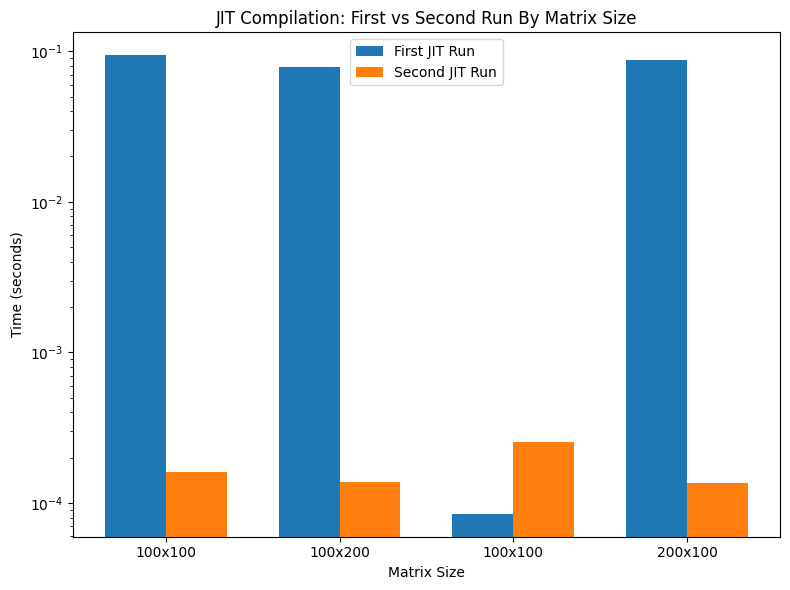

In [9]:
import numpy as np

# Prepare data for grouped bar chart
import matplotlib.pyplot as plt

size_labels = [f"{r}x{c}" for (r, c) in sizes]
x = np.arange(len(sizes))  # group locations

width = 0.35  # width of the bars

fig, ax = plt.subplots(figsize=(8, 6))

rects1 = ax.bar(x - width/2, first_jit_times, width, label='First JIT Run')
rects2 = ax.bar(x + width/2, second_jit_times, width, label='Second JIT Run')

# Add labels, title, ticks, legend
ax.set_ylabel('Time (seconds)')
ax.set_xlabel('Matrix Size')
ax.set_title('JIT Compilation: First vs Second Run By Matrix Size')
ax.set_xticks(x)
ax.set_xticklabels(size_labels)
ax.set_yscale('log')
ax.legend()

plt.tight_layout()
plt.show()

JAX retraces when it sees a size different than it has seen before. So when it uses 100x100 for the second time, there is no recompilation and the two runs are basically the same amount of time. The performance impact is massive, the retracing for this specific function is orders of magnitude more than one single compiled run.

In [ ]:
def trig_powers_eager(x):
    sum = 0
    sinx = x
    cosx = x
    for i in range(1, 101):
        sinx = jnp.sin(sinx)
        cosx = jnp.cos(cosx)
        sum += sinx + cosx
    return sum

@jax.jit
def trig_powers_jit(x):
    def body(i, carry):
        sin_acc, cos_acc, total = carry
        sin_acc = jnp.sin(sin_acc)
        cos_acc = jnp.cos(cos_acc)
        return (sin_acc, cos_acc, total + sin_acc + cos_acc)

    return jax.lax.fori_loop(1, 101, body, (x, x, jnp.zeros_like(x)))[2]

In [14]:
import torch
from torch.profiler import profile, ProfilerActivity

x = jax.random.normal(jax.random.PRNGKey(0), (5000, 5000))

with profile(activities=[ProfilerActivity.CUDA]) as eager_prof:
    for _ in range(10):
        trig_powers_eager(x).block_until_ready()

print(eager_prof.key_averages().table(sort_by="cuda_time_total", row_limit=30))

----------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                              Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
----------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                       wrapped_add         0.00%       0.000us         0.00%       0.000us       0.000us     731.303ms        60.68%     731.303ms     371.597us          1968  
                    wrapped_cosine         0.00%       0.000us         0.00%       0.000us       0.000us     238.472ms        19.79%     238.472ms     241.369us           988  
                      wrapped_sine         0.00%       0.000us         0.00%       0.000us       0.000us     233.4

In [15]:
trig_powers_jit(x).block_until_ready()

with profile(activities=[ProfilerActivity.CUDA]) as jit_prof:
    for _ in range(10):
        trig_powers_jit(x).block_until_ready()

print(jit_prof.key_averages().table(sort_by="cuda_time_total", row_limit=30))

----------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                              Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
----------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
       loop_add_cosine_sine_fusion         0.00%       0.000us         0.00%       0.000us       0.000us     748.444ms        99.20%     748.444ms     768.423us           974  
    Memcpy DtoD (Device -> Device)         0.00%       0.000us         0.00%       0.000us       0.000us       3.659ms         0.48%       3.659ms     135.512us            27  
                   loop_add_fusion         0.00%       0.000us         0.00%       0.000us       0.000us       1.4

# Eager (no JIT) mode:
# - Number of kernels launched: 4000
# - Total execution time: 1.205s
# - Memory throughput: 
    5000*5000*4 bytes = 100mb
    100mb in + 100mb out = 200mb for sin, cos (x2000)
    200mb in + 100mb out = 300mb for addition (x2000)
    = 1,000,000mb or 1TB/1.205s ~ 830GB/s
#
# JAX JIT mode:
# - Number of kernels launched: 2010
# - Total execution time: 754.5ms
# - Memory throughput: 
    5000*5000*4 bytes = 100mb
    200mb in + 100mb out = 300mb for sin + cos (x1000)
    200mb in + 100mb out = 300mb for loop add (x1000)
    = 600,000mb or 600GB/0.754s ~ 800GB/s

JIT runs about 40% faster due to fusing the addition of the sine and cosine outputs together and then adding to the carried value. Eager has a separate add, cosine, sine, and add to carry kernel for each one. As the kernel launch is around 98% of both, cutting kernel launches by half cuts the compute time also about in half, showing how the kernel is most of the bottleneck to performance.

The theoretical speedup would be ~50% as it cuts kernel launches about in half, but there is still enough compute that it's a bit less than that.